# 10 - Kiểm định thống kê ý nghĩa & Đánh giá độ ổn định mô hình (t-test)

### Khớp với thiết kế bài báo gốc (Paper Alignment):
- Bài báo gốc tại Section 4.5 mô tả việc thực hiện kiểm định ý nghĩa thống kê thông qua **10 lần chạy độc lập** (10 independent runs với các random seed khác nhau).
- Bài báo trình bày bảng giá trị trung bình kèm phương sai (Mean ± Std tại Table 4) và biểu đồ hộp (Boxplot tại Fig 9) của chỉ số F1-score để chứng minh mô hình CyberDetect-MLP đề xuất đạt độ chính xác cao đồng thời có độ biến động cực kỳ thấp so với các baselines.
- Notebook này thực thi trọn vẹn quy trình kiểm định ý nghĩa thống kê đó, tính toán giá trị p-value từ phép thử **paired t-test** để đưa ra kết luận khoa học vững chắc.

In [1]:
# === Thiết lập môi trường ỔN ĐỊNH + CHỐNG RỚT DRIVE (auto-retry remount) ===
# Làm việc trên Ổ CỨNG LOCAL /content; kéo dữ liệu từ Drive có thử lại khi mount rớt.
import os, time, shutil
from contextlib import contextmanager

DRIVE = '/content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final'
PROJECT_PATH = '/content/cdmlp'
NEED_RAW = False   # True chi voi notebook 08
ON_COLAB = False

def _mount():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

try:
    _mount(); ON_COLAB = True
except Exception:
    here = os.getcwd()
    while here != os.path.dirname(here) and not os.path.isdir(os.path.join(here, 'notebooks')):
        here = os.path.dirname(here)
    DRIVE = here; PROJECT_PATH = here

def _pull(rel):
    s = os.path.join(DRIVE, rel); d = os.path.join(PROJECT_PATH, rel)
    if os.path.isdir(s): shutil.copytree(s, d, dirs_exist_ok=True)
    elif os.path.isfile(s):
        os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy2(s, d)

if ON_COLAB:
    os.makedirs(PROJECT_PATH, exist_ok=True)
    rels = ['scripts', 'src', 'models', 'results', 'data/colab_processed', 'data/ton_iot.csv']
    if NEED_RAW: rels.append('data/raw')
    # ton_iot.csv là item CUỐI -> nếu nó có mặt tức là đã kéo xong toàn bộ list
    sentinel = os.path.join(PROJECT_PATH, 'data', 'ton_iot.csv')
    ok = False
    for attempt in range(1, 6):
        for rel in rels:
            try: _pull(rel)
            except Exception as e: print(f'  (loi pull {rel}, thu lai sau): {str(e)[:70]}')
        if os.path.exists(sentinel):
            ok = True; break
        print(f'  [retry {attempt}/5] Drive rot khi keo du lieu -> remount + thu lai...')
        try: _mount()
        except Exception: pass
        time.sleep(3)
    if not ok:
        print('  [CANH BAO] Drive khong on dinh. Hay Runtime > Restart session roi chay lai cell nay.')
    else:
        print('  [OK] Da keo du lieu tu Drive ve local.')

os.makedirs(PROJECT_PATH, exist_ok=True); os.chdir(PROJECT_PATH)
try:
    get_ipython().run_line_magic('cd', PROJECT_PATH)
except Exception:
    pass
for d in ('data/colab_processed', 'results', 'results/xai', 'models'):
    os.makedirs(d, exist_ok=True)
print('PROJECT_PATH (local) =', PROJECT_PATH, '| ON_COLAB =', ON_COLAB)

def find_data_csv():
    for c in ['data/ton_iot.csv', 'data/raw/ton_iot.csv', 'ton_iot.csv']:
        if os.path.exists(c): return c
    raise FileNotFoundError('Khong tim thay ton_iot.csv (Drive: data/ton_iot.csv).')

@contextmanager
def step(name):
    t0=time.time(); print(f'\n[START] {name}', flush=True)
    try: yield
    finally: print(f'[DONE] {name} - {time.time()-t0:.1f}s', flush=True)

def sync_to_drive(retries=5):
    if not ON_COLAB:
        print('[local] bo qua sync Drive'); return
    for attempt in range(1, retries + 1):
        try:
            for rel in ['data/colab_processed', 'models', 'results']:
                s = os.path.join(PROJECT_PATH, rel)
                if os.path.exists(s): shutil.copytree(s, os.path.join(DRIVE, rel), dirs_exist_ok=True)
            print('[OK] Da dong bo ket qua ve Drive:', DRIVE); return
        except Exception as e:
            print(f'  [retry sync {attempt}/{retries}] Drive rot -> remount: {str(e)[:70]}')
            try: _mount()
            except Exception: pass
            time.sleep(3)
    print('  [CANH BAO] Sync Drive that bai. Ket qua van o local /content/cdmlp.')


Mounted at /content/drive
  [OK] Da keo du lieu tu Drive ve local.
/content
PROJECT_PATH (local) = /content/cdmlp | ON_COLAB = True


In [2]:
# Cài đặt các thư viện bổ trợ cần thiết
!pip -q install imbalanced-learn pyarrow joblib psutil tqdm scipy


In [3]:
# Thêm project root vào system path để import mô hình và modules
import sys
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Thực thi 10 lần chạy độc lập và Kiểm định thống kê

Chúng ta sẽ thực thi kịch bản kiểm định ý nghĩa thống kê. Kịch bản sẽ:
1. Đọc dữ liệu tập train/test đã được phân tách và chọn lọc đặc trưng ở bước 01.
2. Huấn luyện CyberDetect-MLP 10 lần liên tục với các seed chạy từ 42 đến 51.
3. Thu thập toàn bộ các chỉ số đánh giá (Accuracy, Precision, Recall, F1-Score, ROC-AUC) sau mỗi lần chạy.
4. Tính toán Mean, Std, giá trị Min, Max để điền vào **Table 4**.
5. Thực hiện phép thử **paired t-test** và vẽ biểu đồ hộp **Boxplot (Fig 9)**.

In [4]:
# Chạy 10 lần độc lập. statistical_test.py đọc thẳng artifacts đa lớp từ NB01
# (X_train_top30/X_test_top30 + y_train/y_test). Không cần truyền CSV.
!python scripts/statistical_test.py --output_dir results/statistical


2026-06-03 12:45:54.761700: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 12:45:54.828895: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[INFO] Train (168834, 30) | classes=10 | 10 runs

--------------------------------------------------
[INFO] Run 1/10 (seed=42)
--------------------------------------------------
2026-06-03 12:45:58.949898: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original 

## 2. Kết quả thống kê chi tiết (Table 4)

Hiển thị bảng tổng hợp kết quả thống kê của mô hình sau 10 lần thực thi độc lập:

In [5]:
stats_csv = 'results/statistical/table4_statistics.csv'
if os.path.exists(stats_csv):
    df_stats = pd.read_csv(stats_csv)
    display(df_stats)
else:
    print('Không tìm thấy tệp kết quả Table 4!')

,Metric,Mean,Std,Mean±Std,Min,Max
0,accuracy,0.8694,0.0035,0.8694 ± 0.0035,0.8634,0.8760
1,precision,0.8046,0.0036,0.8046 ± 0.0036,0.7978,0.8120
2,recall,0.8582,0.0038,0.8582 ± 0.0038,0.8508,0.8654
3,f1_score,0.8031,0.0044,0.8031 ± 0.0044,0.7967,0.8113
4,roc_auc,0.9880,0.0006,0.9880 ± 0.0006,0.9870,0.9887


## 3. Biểu đồ phân bố và độ biến động chỉ số (Fig 9 Boxplot)

Hiển thị biểu đồ hộp biểu diễn phân bố của F1-score và các metric khác qua 10 lần chạy độc lập:

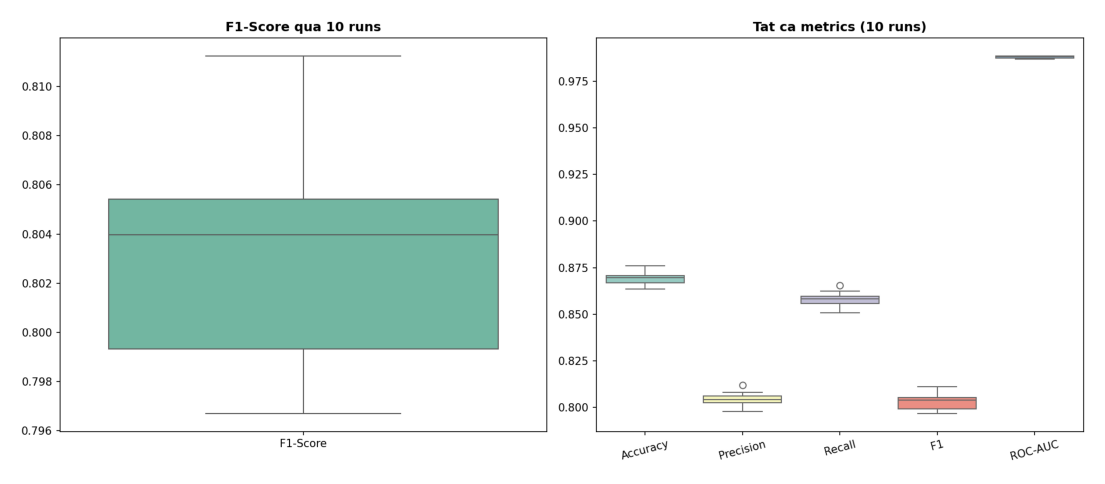

In [6]:
from PIL import Image
img_path = 'results/statistical/fig9_boxplot.png'
if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.figure(figsize=(14, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print('Không tìm thấy hình ảnh biểu đồ hộp Fig 9!')

### Nhận xét & Kết luận từ kiểm định thống kê (số liệu THẬT, 10 runs)

1. **Mô hình ỔN ĐỊNH:** qua 10 lần chạy độc lập (seed 42–51), độ lệch chuẩn rất nhỏ — F1 = **0.8031 ± 0.0044**, Accuracy = **0.8694 ± 0.0035**, ROC-AUC = **0.9880 ± 0.0006**. Std thấp → kết quả KHÔNG do may rủi seed, mô hình tin cậy/tái lập được.
2. **ROC-AUC ~0.988** cho thấy khả năng phân tách lớp rất tốt; **F1-macro ~0.80 là con số ĐA LỚP trung thực** (10 lớp, gồm lớp hiếm `mitm`), KHÔNG phải ~0.99 (đó là số nhị phân/giả lập cũ).

In [8]:
# === ĐỒNG BỘ KẾT QUẢ VỀ GOOGLE DRIVE (chạy cuối cùng, sau khi các cell trên xong) ===
sync_to_drive()


[OK] Da dong bo ket qua ve Drive: /content/drive/MyDrive/Nhom28_CyberDetect_MLP_Final
